# Session 2

In [1]:
# Laden der notwendigen Bibliotheken
import pandas as pd
import numpy as np
import sklearn
from sklearn import linear_model
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

## Splitting von Daten

In [3]:
wage_data = pd.read_csv("wage_data.csv")

train_data, test_data = train_test_split(wage_data, test_size=0.3, random_state=0)
val_data, test_data = train_test_split(test_data, test_size=0.5, random_state=3)

print(len(train_data), len(val_data), len(val_data), "\n")

print("Trainingsdaten:", round(len(train_data) / len(wage_data)*100),"%")
print("Validierungsdaten:", round(len(val_data) / len(wage_data)*100),"%")
print("Testdaten:", round(len(test_data) / len(wage_data)*100),"%")

368 79 79 

Trainingsdaten: 70 %
Validierungsdaten: 15 %
Testdaten: 15 %


In [4]:
X_train = train_data.drop("wage", axis=1)
y_train = train_data["wage"]
X_val = val_data.drop("wage", axis=1)
y_val = val_data["wage"]
X_test = test_data.drop("wage", axis=1)
y_test = test_data["wage"]

In [5]:
linear_regression = linear_model.LinearRegression().fit(X_train, y_train)
print("Training R^2 Wert", round(linear_regression.score(X_train, y_train),3))
print("Validation R^2 Wert", round(linear_regression.score(X_val, y_val),3))
print("Test R^2 Wert", round(linear_regression.score(X_test, y_test),3))

Training R^2 Wert 0.36
Validation R^2 Wert 0.279
Test R^2 Wert 0.438


## Fehlende Daten

In [6]:
birthweight_data = pd.read_csv("birthweight_data.csv")
birthweight_data

,faminc,cigtax,cigprice,bwght,fatheduc,motheduc,parity,male,white,cigs,bwghtlbs
0,13.5,16.5,122.300003,109,12.0,12.0,1,1,1,0,6.8125
1,7.5,16.5,122.300003,133,6.0,12.0,2,1,0,0,8.3125
2,0.5,16.5,122.300003,129,NaN,12.0,2,0,0,0,8.0625
3,15.5,16.5,122.300003,126,12.0,12.0,2,1,0,0,7.8750
4,27.5,16.5,122.300003,134,14.0,12.0,2,1,1,0,8.3750
...,...,...,...,...,...,...,...,...,...,...,...
1383,27.5,30.0,138.300003,110,12.0,12.0,4,1,1,0,6.8750
1384,5.5,30.0,138.300003,146,NaN,16.0,2,1,1,0,9.1250
1385,65.0,8.0,118.599998,135,18.0,16.0,2,0,1,0,8.4375
1386,27.5,8.0,118.599998,118,NaN,14.0,2,0,1,0,7.3750


In [7]:
birthweight_data.isna().mean()

faminc      0.00000
cigtax      0.00000
cigprice    0.00000
bwght       0.00000
fatheduc    0.14121
motheduc    0.00072
parity      0.00000
male        0.00000
white       0.00000
cigs        0.00000
bwghtlbs    0.00000
dtype: float64

In [8]:
# Entfernen der Reihen mit NA Werten:
birthweight_data.dropna()

,faminc,cigtax,cigprice,bwght,fatheduc,motheduc,parity,male,white,cigs,bwghtlbs
0,13.5,16.5,122.300003,109,12.0,12.0,1,1,1,0,6.8125
1,7.5,16.5,122.300003,133,6.0,12.0,2,1,0,0,8.3125
3,15.5,16.5,122.300003,126,12.0,12.0,2,1,0,0,7.8750
4,27.5,16.5,122.300003,134,14.0,12.0,2,1,1,0,8.3750
5,7.5,16.5,122.300003,118,12.0,14.0,6,1,0,0,7.3750
...,...,...,...,...,...,...,...,...,...,...,...
1381,12.5,30.0,138.300003,87,14.0,12.0,1,1,1,0,5.4375
1382,22.5,30.0,138.300003,135,16.0,16.0,3,0,1,0,8.4375
1383,27.5,30.0,138.300003,110,12.0,12.0,4,1,1,0,6.8750
1385,65.0,8.0,118.599998,135,18.0,16.0,2,0,1,0,8.4375


In [9]:
# Entfernen der Spalten mit NA Werten:
birthweight_data.dropna(axis=1)

,faminc,cigtax,cigprice,bwght,parity,male,white,cigs,bwghtlbs
0,13.5,16.5,122.300003,109,1,1,1,0,6.8125
1,7.5,16.5,122.300003,133,2,1,0,0,8.3125
2,0.5,16.5,122.300003,129,2,0,0,0,8.0625
3,15.5,16.5,122.300003,126,2,1,0,0,7.8750
4,27.5,16.5,122.300003,134,2,1,1,0,8.3750
...,...,...,...,...,...,...,...,...,...
1383,27.5,30.0,138.300003,110,4,1,1,0,6.8750
1384,5.5,30.0,138.300003,146,2,1,1,0,9.1250
1385,65.0,8.0,118.599998,135,2,0,1,0,8.4375
1386,27.5,8.0,118.599998,118,2,0,1,0,7.3750


In [11]:
# Ersetzen der fehlenden Daten durch Mittelwert / Median / Modus 
# Also possible with sklearn SimpleImputer
birthweigh_filled_copy = birthweight_data.copy()
birthweigh_filled_copy["fatheduc"] = birthweight_data["fatheduc"].fillna(birthweight_data["fatheduc"].mean())
birthweigh_filled_copy["motheduc"] = birthweight_data["motheduc"].fillna(birthweight_data["motheduc"].median())
birthweigh_filled_copy.isna().sum()
birthweigh_filled_copy

,faminc,cigtax,cigprice,bwght,fatheduc,motheduc,parity,male,white,cigs,bwghtlbs
0,13.5,16.5,122.300003,109,12.000000,12.0,1,1,1,0,6.8125
1,7.5,16.5,122.300003,133,6.000000,12.0,2,1,0,0,8.3125
2,0.5,16.5,122.300003,129,13.186242,12.0,2,0,0,0,8.0625
3,15.5,16.5,122.300003,126,12.000000,12.0,2,1,0,0,7.8750
4,27.5,16.5,122.300003,134,14.000000,12.0,2,1,1,0,8.3750
...,...,...,...,...,...,...,...,...,...,...,...
1383,27.5,30.0,138.300003,110,12.000000,12.0,4,1,1,0,6.8750
1384,5.5,30.0,138.300003,146,13.186242,16.0,2,1,1,0,9.1250
1385,65.0,8.0,118.599998,135,18.000000,16.0,2,0,1,0,8.4375
1386,27.5,8.0,118.599998,118,13.186242,14.0,2,0,1,0,7.3750


In [12]:
# Nutzen der sklearn Methoden oder manuelle Implementierung
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer # Alternative: KNNImputer
imputer = IterativeImputer(random_state=0).set_output(transform="pandas")
birthweigh_filled_copy = imputer.fit_transform(birthweight_data)
print("Number of NA values: ", birthweigh_filled_copy.isna().sum().sum())

Number of NA values:  0


In [13]:
birthweigh_filled_copy

,faminc,cigtax,cigprice,bwght,fatheduc,motheduc,parity,male,white,cigs,bwghtlbs
0,13.5,16.5,122.300003,109.0,12.000000,12.0,1.0,1.0,1.0,0.0,6.8125
1,7.5,16.5,122.300003,133.0,6.000000,12.0,2.0,1.0,0.0,0.0,8.3125
2,0.5,16.5,122.300003,129.0,11.398633,12.0,2.0,0.0,0.0,0.0,8.0625
3,15.5,16.5,122.300003,126.0,12.000000,12.0,2.0,1.0,0.0,0.0,7.8750
4,27.5,16.5,122.300003,134.0,14.000000,12.0,2.0,1.0,1.0,0.0,8.3750
...,...,...,...,...,...,...,...,...,...,...,...
1383,27.5,30.0,138.300003,110.0,12.000000,12.0,4.0,1.0,1.0,0.0,6.8750
1384,5.5,30.0,138.300003,146.0,14.486050,16.0,2.0,1.0,1.0,0.0,9.1250
1385,65.0,8.0,118.599998,135.0,18.000000,16.0,2.0,0.0,1.0,0.0,8.4375
1386,27.5,8.0,118.599998,118.0,13.407292,14.0,2.0,0.0,1.0,0.0,7.3750


In [14]:
# Number of changed values:
(birthweigh_filled_copy != birthweight_data).sum()

faminc        0
cigtax        0
cigprice      0
bwght         0
fatheduc    196
motheduc      1
parity        0
male          0
white         0
cigs          0
bwghtlbs      0
dtype: int64

## Overfitting

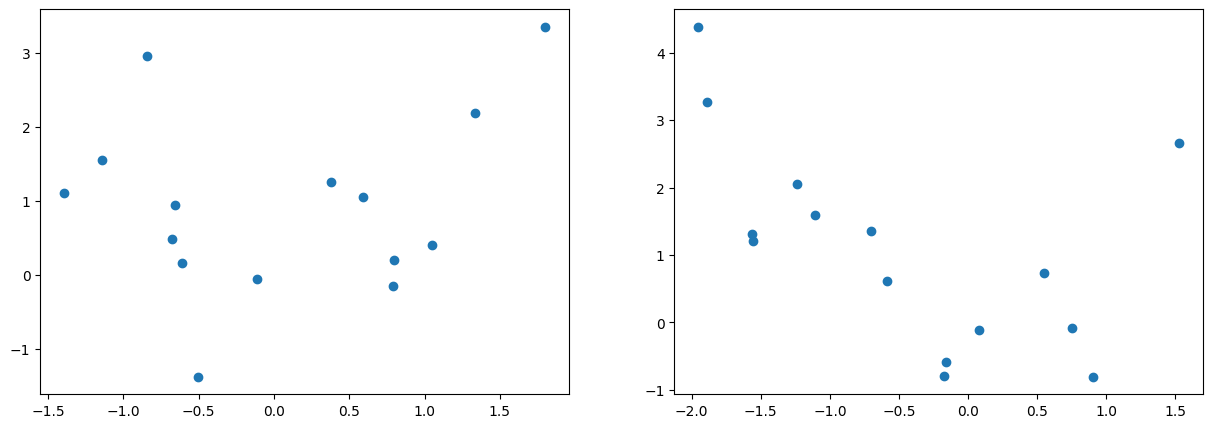

In [22]:
# Neuen Datensatz erstellen und aufteilen
x_all = np.random.uniform(-2,2,30)
noise = np.random.normal(0, 0.5, x_all.shape)
y_all = x_all * x_all + np.sin(5*x_all) + noise
x_train, x_val, y_train, y_val = train_test_split(x_all, y_all, test_size = 0.5)

# Plot von Trainings und Testdaten
fig, axs = plt.subplots(1,2,figsize=(15,5))
axs[0].plot(x_train, y_train, 'o')
axs[1].plot(x_val, y_val, 'o')

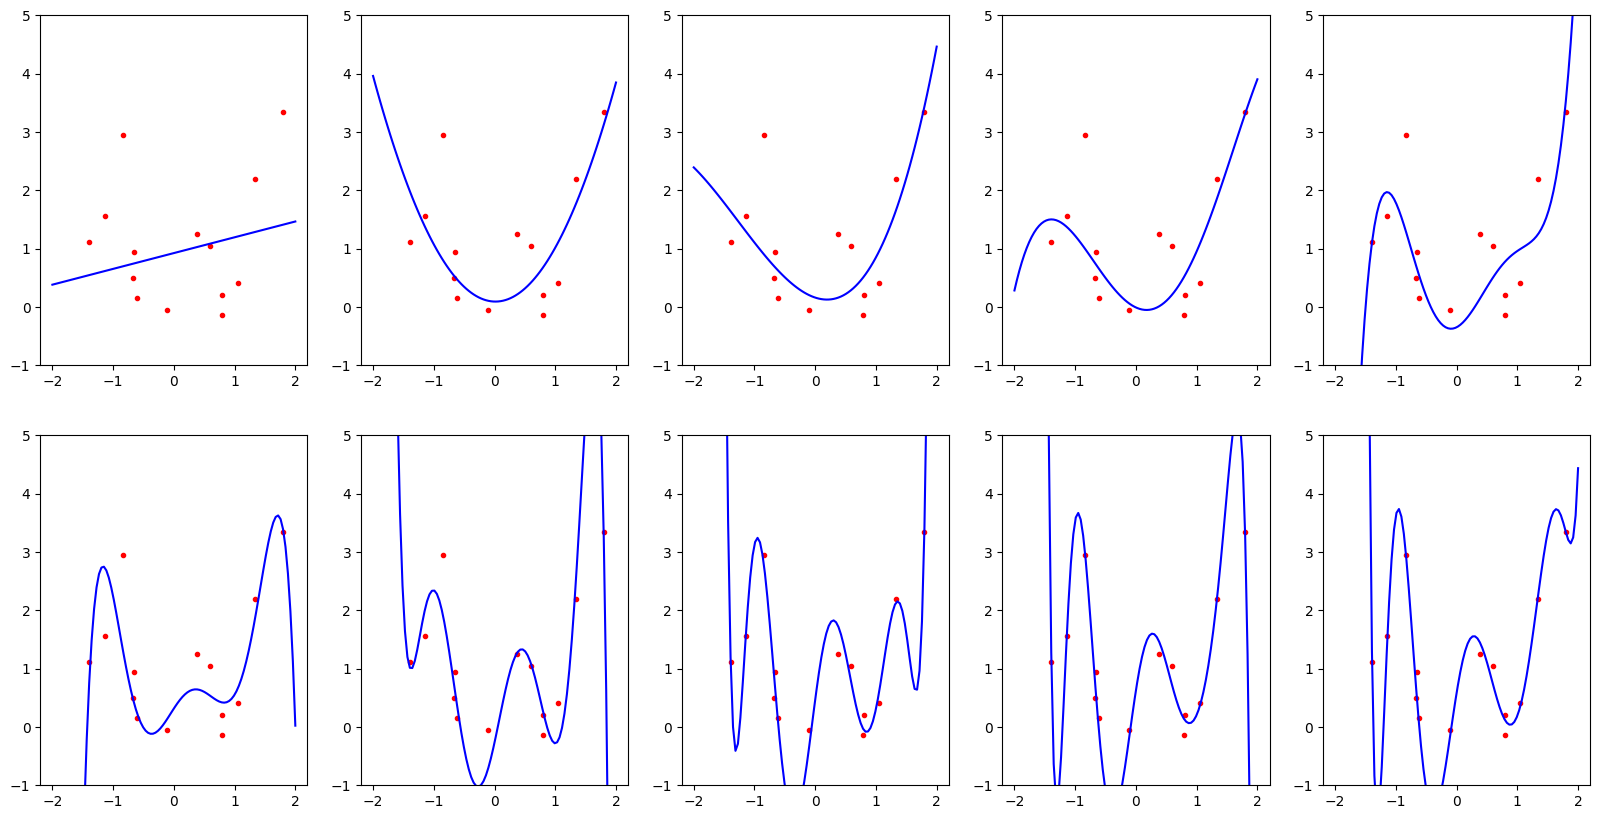

In [23]:
# Vorbereitung der Daten für polynomische Funktion
x_train = x_train.reshape(-1, 1)
xx_train = PolynomialFeatures(degree = 10).fit_transform(x_train)
x_plot = np.linspace(-2, 2, 100)
x_plot = x_plot.reshape(-1, 1)
xx_plot = PolynomialFeatures(degree = 10).fit_transform(x_plot)


fig = plt.figure(figsize=(20,10))
for i in range(1, 11):
    # Plot der Trainingsdaten
    ax = fig.add_subplot(2, 5, i)
    ax.set_ylim([-1,5])
    ax.plot (x_train, y_train, 'r.')

    # Plot der Regressionsfunktion
    regr = linear_model.LinearRegression().fit(xx_train[:,0:(i+1)], y_train)
    ax.plot (x_plot, regr.predict(xx_plot[:,0:(i+1)]), 'b')

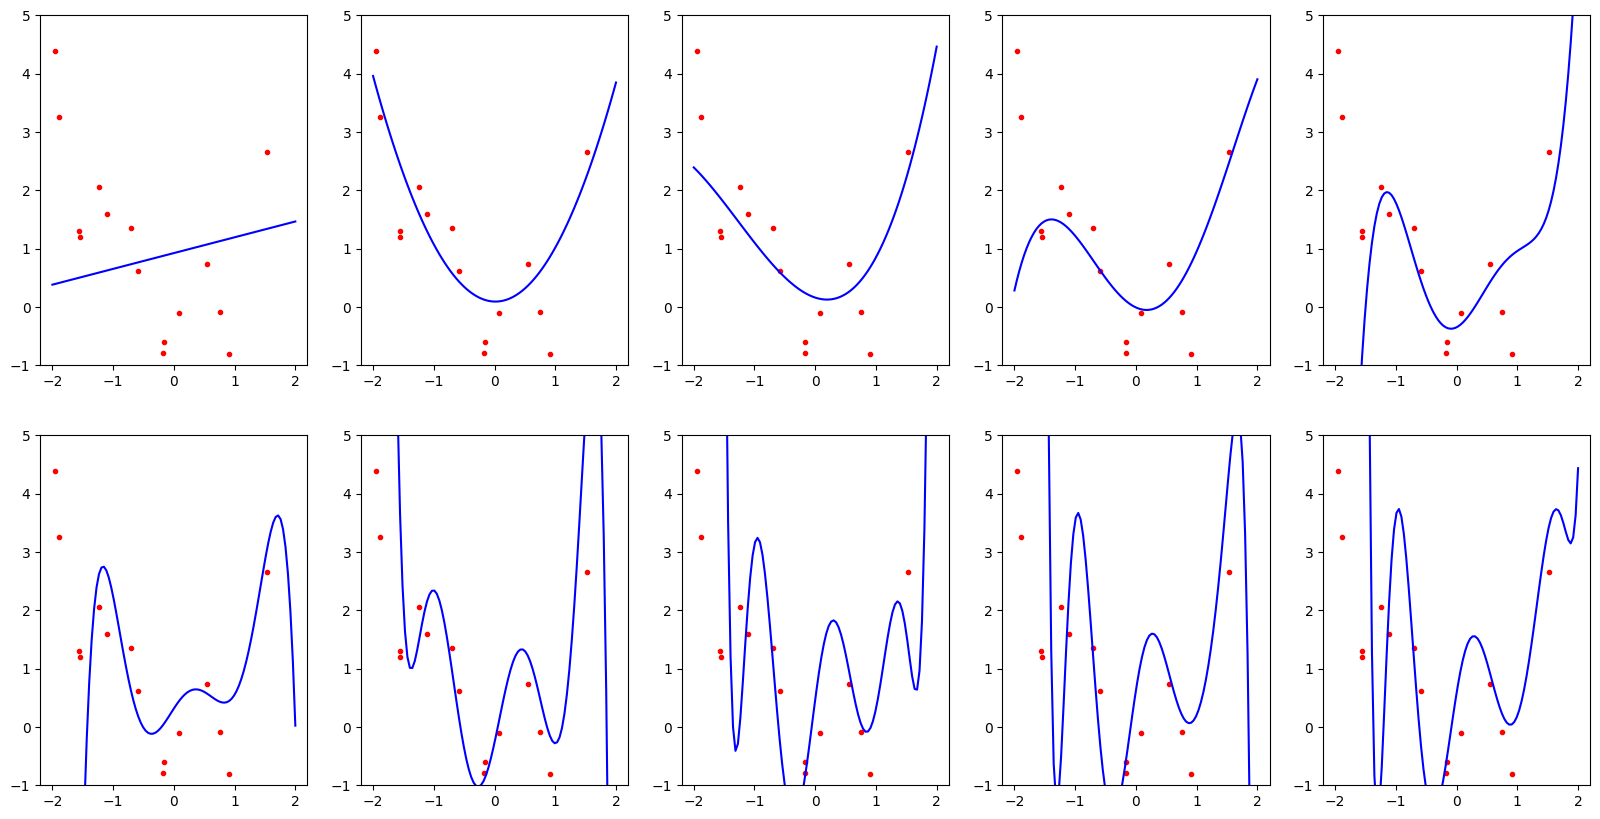

In [24]:
# Plot der Regressionsfunktion gegenüber der Testdaten
fig = plt.figure(figsize=(20,10))

for i in range(1, 11):
    # Plot der Testdaten
    ax = fig.add_subplot(2, 5, i)
    ax.set_ylim([-1,5])
    ax.plot (x_val, y_val, 'r.')

    # Plot der Regressionsfunktion basierend auf den Trainingsdaten
    regr = linear_model.LinearRegression().fit(xx_train[:,0:(i+1)], y_train)
    ax.plot (x_plot, regr.predict(xx_plot[:,0:(i+1)]), 'b')

### Regularisierung

Da eine Strafe auf die Größe der Koeffizienten angewnedet wird, sollten diese alle in etwa die gleiche Größe haben um nicht unterscheidlich viel bestraft zu werden. Daher müssen wir die Daten normalisieren.

In [30]:
wage_data = pd.read_csv("wage_data.csv")

train_data, test_data = train_test_split(wage_data, test_size=0.3, random_state=14)
val_data, test_data = train_test_split(test_data, test_size=0.5, random_state=10)

X_train = train_data.drop("wage", axis=1)
y_train = train_data["wage"]
X_val = val_data.drop("wage", axis=1)
y_val = val_data["wage"]
X_test = test_data.drop("wage", axis=1)
y_test = test_data["wage"]

In [31]:
scaler = sklearn.preprocessing.StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
X_test_scaled[:2]

array([[-0.15072523,  0.1078058 , -0.70024033, -0.35409358, -0.94705186,
         0.81096095],
       [ 1.28067828, -1.04004332, -0.5595807 , -0.35409358,  1.05590839,
        -1.233105  ]])

In [32]:
linear_regression = linear_model.LinearRegression().fit(X_train_scaled, y_train)
print("Training R^2 Wert", round(linear_regression.score(X_train_scaled, y_train),3))
print("Validation R^2 Wert", round(linear_regression.score(X_val_scaled, y_val),3))
print("Test R^2 Wert", round(linear_regression.score(X_test_scaled, y_test),3))

Training R^2 Wert 0.367
Validation R^2 Wert 0.342
Test R^2 Wert 0.344


In [33]:
lasso_regression = linear_model.Lasso(alpha=0.1).fit(X_train_scaled, y_train)
print("Training R^2 Wert", round(lasso_regression.score(X_train_scaled, y_train), 3))
print("Validation R^2 Wert", round(lasso_regression.score(X_val_scaled, y_val), 3))
# Besten Parameter für alpha finden, Hyperparametertuning

Training R^2 Wert 0.363
Validation R^2 Wert 0.359


In [34]:
print("Test R^2 Wert", round(lasso_regression.score(X_test_scaled, y_test),3))

Test R^2 Wert 0.325


In [35]:
training_results = {}
validation_results = {}
for alpha in np.linspace(0.01,1.5,150):
    lasso_regression = linear_model.Lasso(alpha=alpha).fit(X_train_scaled, y_train)
    training_results[alpha] = lasso_regression.score(X_train_scaled, y_train)
    validation_results[alpha] = lasso_regression.score(X_val_scaled, y_val)

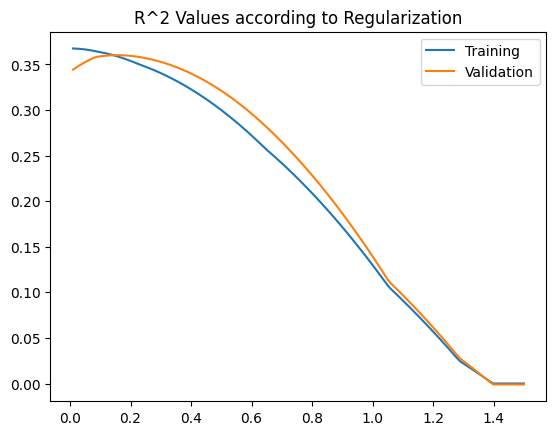

In [36]:
x, y = zip(*training_results.items())
plt.plot(x, y, label="Training")
x, y = zip(*validation_results.items())
plt.plot(x, y, label="Validation")

plt.title("R^2 Values according to Regularization")
plt.legend()
plt.show()

In [37]:
# Finden des besten Alpha wertes basierend auf Validierungsdaten. Alternativ den Wert nehmen wo sich die beiden Linien treffen
lasso_best_alpha = max(validation_results.items(), key=lambda item : item[1])[0]
print("Best Alpha:", lasso_best_alpha)

# Erneutes Training des Modells
lasso_regression = linear_model.Lasso(alpha=lasso_best_alpha).fit(X_train_scaled, y_train)

# Ergebnisse zeigen
print("\nTraining R^2 Wert", round(lasso_regression.score(X_train_scaled, y_train),3))
print("Validation R^2 Wert", round(lasso_regression.score(X_val_scaled, y_val),3))
print("Test R^2 Wert", round(lasso_regression.score(X_test_scaled, y_test),3))

Best Alpha: 0.16

Training R^2 Wert 0.358
Validation R^2 Wert 0.36
Test R^2 Wert 0.311


Wir können dasselbe jetzt auch noch mit der Ridge Regression machen:

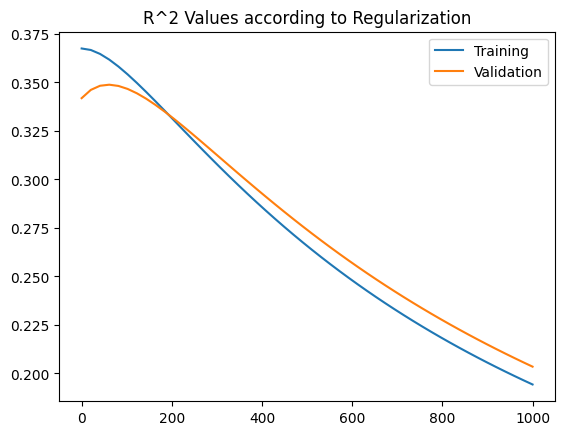

In [38]:
training_results = {}
validation_results = {}
for alpha in np.linspace(0.0001,1000,50):
    ridge_regression = linear_model.Ridge(alpha=alpha).fit(X_train_scaled, y_train)
    training_results[alpha] = ridge_regression.score(X_train_scaled, y_train)
    validation_results[alpha] = ridge_regression.score(X_val_scaled, y_val)

x, y = zip(*training_results.items())
plt.plot(x, y, label="Training")
x, y = zip(*validation_results.items())
plt.plot(x, y, label="Validation")

plt.title("R^2 Values according to Regularization")
plt.legend()
plt.show()

In [39]:
# Finden des besten Alpha wertes basierend auf Validierungsdaten. Alternativ den Wert nehmen wo sich die beiden Linien treffen
ridge_best_alpha = max(validation_results.items(), key=lambda item : item[1])[0]
print("Best Alpha:", ridge_best_alpha)

# Erneutes Training des Modells
ridge_regression = linear_model.Ridge(alpha=ridge_best_alpha).fit(X_train_scaled, y_train)

# Ergebnisse zeigen
print("\nTraining R^2 Wert", round(ridge_regression.score(X_train_scaled, y_train),3))
print("Validation R^2 Wert", round(ridge_regression.score(X_val_scaled, y_val),3))
print("Test R^2 Wert", round(ridge_regression.score(X_test_scaled, y_test),3))

Best Alpha: 61.22458367346939

Training R^2 Wert 0.362
Validation R^2 Wert 0.349
Test R^2 Wert 0.313


## Logistic Regression

Vorhersage ob eine Person weiblich ist oder nicht:

In [26]:
X_train = train_data.drop("female", axis=1)
y_train = train_data["female"]
X_val = val_data.drop("female", axis=1)
y_val = val_data["female"]
X_test = test_data.drop("female", axis=1)
y_test = test_data["female"]

In [27]:
log_regression = linear_model.LogisticRegression().fit(X_train, y_train)
print("Training Accuracy", round(log_regression.score(X_train, y_train),3))
print("Validation Accuracy", round(log_regression.score(X_val, y_val),3))
print("Test Accuracy", round(log_regression.score(X_test, y_test),3))

Training Accuracy 0.671
Validation Accuracy 0.696
Test Accuracy 0.646


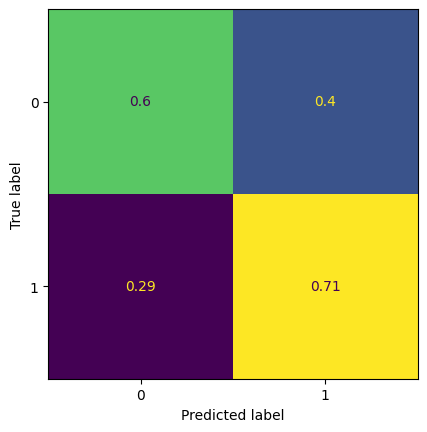

In [28]:
# Visualisierung des Ergebnisses:
sklearn.metrics.ConfusionMatrixDisplay.from_estimator(log_regression, X_test, y_test,
                                                      normalize="true", colorbar=False)
plt.show()